# 人工审核：从这里开始

这里的 **cell 就是 Notebook 中的一块内容**。文字框是说明，不用修改；代码框左边有运行按钮，点它或按 `Shift+Enter` 就会执行。本页只需要操作 **①②③ 三个代码框**，看标题即可，不用找编辑器的 cell 编号。

## 我们在做什么，为什么要你来看？

我们要建立一个小规模、可靠的知识核心集，后面用于文生图与图像编辑出题。它不是“好看图片合集”：我们要知道**某条知识有无来源、在什么条件下成立、图片具体能呈现什么、能否据此出题**。

我已让本地 Qwen 对少量资料提取知识，再看候选图片，生成初稿。程序检查过格式与引文是否存在；这仍不代表结论正确。比如它可能认错同名概念、把“许多”改成“所有”，或看到极光外观就认为图片解释了形成机制。

本批目前有 27 条知识卡、27 条图片卡等待人工判断（剩余数量以①输出为准）。**你不需要一次做完，也不用从头写标注。今天先看 3 条，验证这个流程是否顺手。**

## 两种卡，你分别要干什么？

| 卡片 | 页面会提供什么 | 你要判断什么 |
| --- | --- | --- |
| 知识卡（先出现） | 一句知识、适用条件、来源引文和上下文、分类与画面设想 | 原文是否支持这句话，范围是否准确，这条知识及标签是否适合收录 |
| 图片卡（后出现） | 已提取的知识、候选图、模型看到的内容、两种出题用途的建议 | 模型有没有看错或推断过头；文生图、编辑两项判断是否合理 |

**知识内容类型**回答“描述什么”：特征与结构、属性与状态、关系与组织、过程与变化、功能与机制、规则与约定。**知识领域**回答“属于哪个学科或主题”，对应我们讨论的 29 个领域。它们是两个维度，不必二选一，也不需要你手动把 29 个领域填一遍。

不熟悉领域、看不懂英文来源、证据不够，都可以选 **拿不准** 并说明原因。它会留下待处理记录，不会被当作通过；你不需要凭常识硬猜。

## 操作路线

第一次：**① 开始审核 → ② 看一条 → ③ 保存判断**。之后重复 **② → ③**。只看不保存也可以。

**不要点“全部运行”**：③会保存你填写的判断，逐条看完再运行它。本页不会调用模型；只有③会写入人工审核记录，不会修改原始图片或模型结果。


## ① 开始审核：每次打开只运行一次

把下面 `审核人 = ""` 的引号里填上你的姓名或固定昵称，例如 `审核人 = "研究者A"`，用于记录是谁判断的。其他代码不用改。

运行后应看到“待审核：知识卡 … 条，图片卡 … 条”。若找不到模块或没有 Python 内核，不要继续③；把报错发给我即可。


In [7]:
# ① 开始审核 —— 只改审核人
审核人 = ""

from pathlib import Path
import sys
repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'curation/core.py').exists())
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
from curation.core import DEFAULT_RUN
from curation.review import ReviewQueue
queue = ReviewQueue(DEFAULT_RUN, reviewer=审核人, split='calibration')
queue.summary()
if not 审核人.strip():
    print('你可以先看卡片；保存前请填好本格的审核人并重新运行①。')


待审核：知识卡 26 条，图片卡 27 条。
先核对知识，再看图片。今天先做 3 条即可；关闭后可继续，已保存的条目会自动跳过。
接下来运行「② 看一条」，只读展示，不会调用模型或写入审核。
你可以先看卡片；保存前请填好本格的审核人并重新运行①。


## ② 看一条：每审核一条都从这里开始

直接运行下面代码，不用改。结果出现在代码框下方。

- **知识卡**：先读知识句子，再读来源引文；需要更多背景就点“展开引用前后的上下文”。核对有没有张冠李戴、遗漏限制、夸大结论，再看分类及画面设想。
- **图片卡**：先看原图，再核对模型描述，最后看文生图和编辑的建议。外观像不等于能证明机制；编辑还要看原图是否提供足够条件，修改是否确实依赖知识。

页面中的“模型草稿”“模型建议”都不是标准答案。看不准时记下具体疑问即可。“技术明细”可以不展开。

尚未保存时再次运行②，会展示同一条；③保存后再运行②，才会出现下一条。


### 知识卡：核对一句知识 · 螺栓

图片进度：这条知识有 2 张已完成标注的候选图，下面先供对照；图片结论稍后在图片卡单独审核。


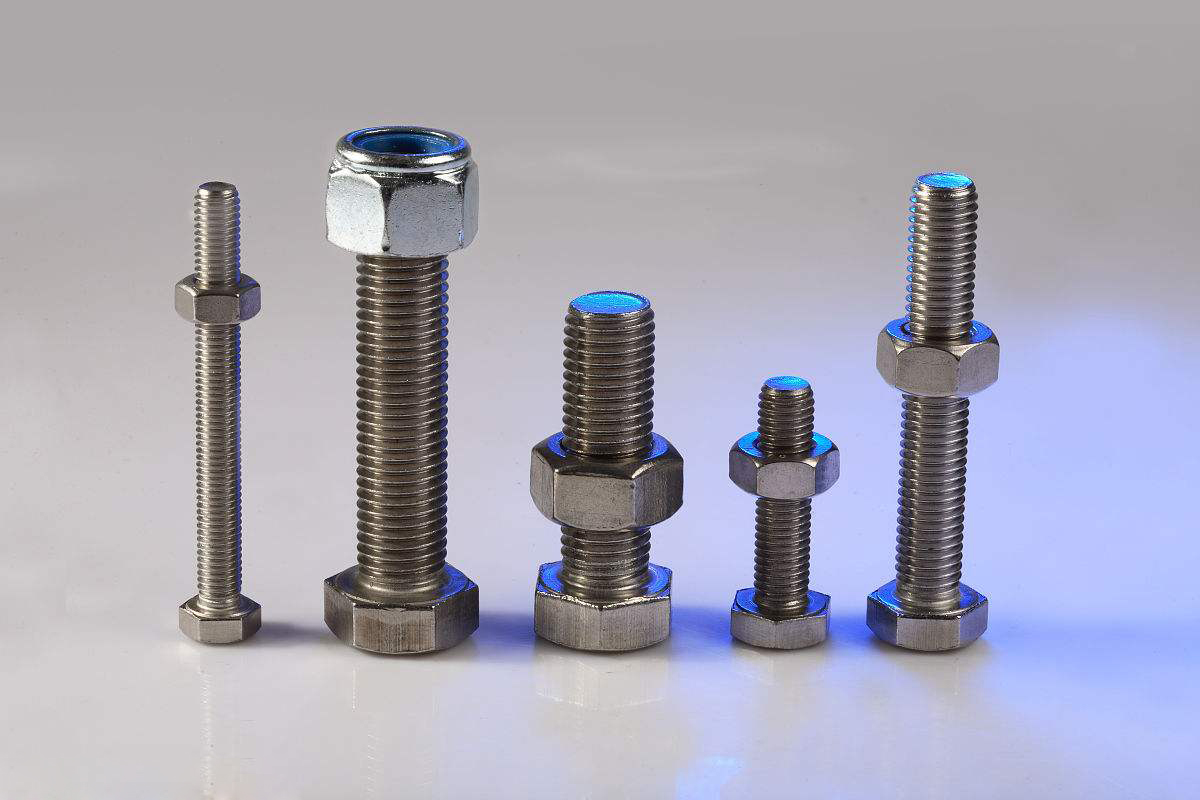

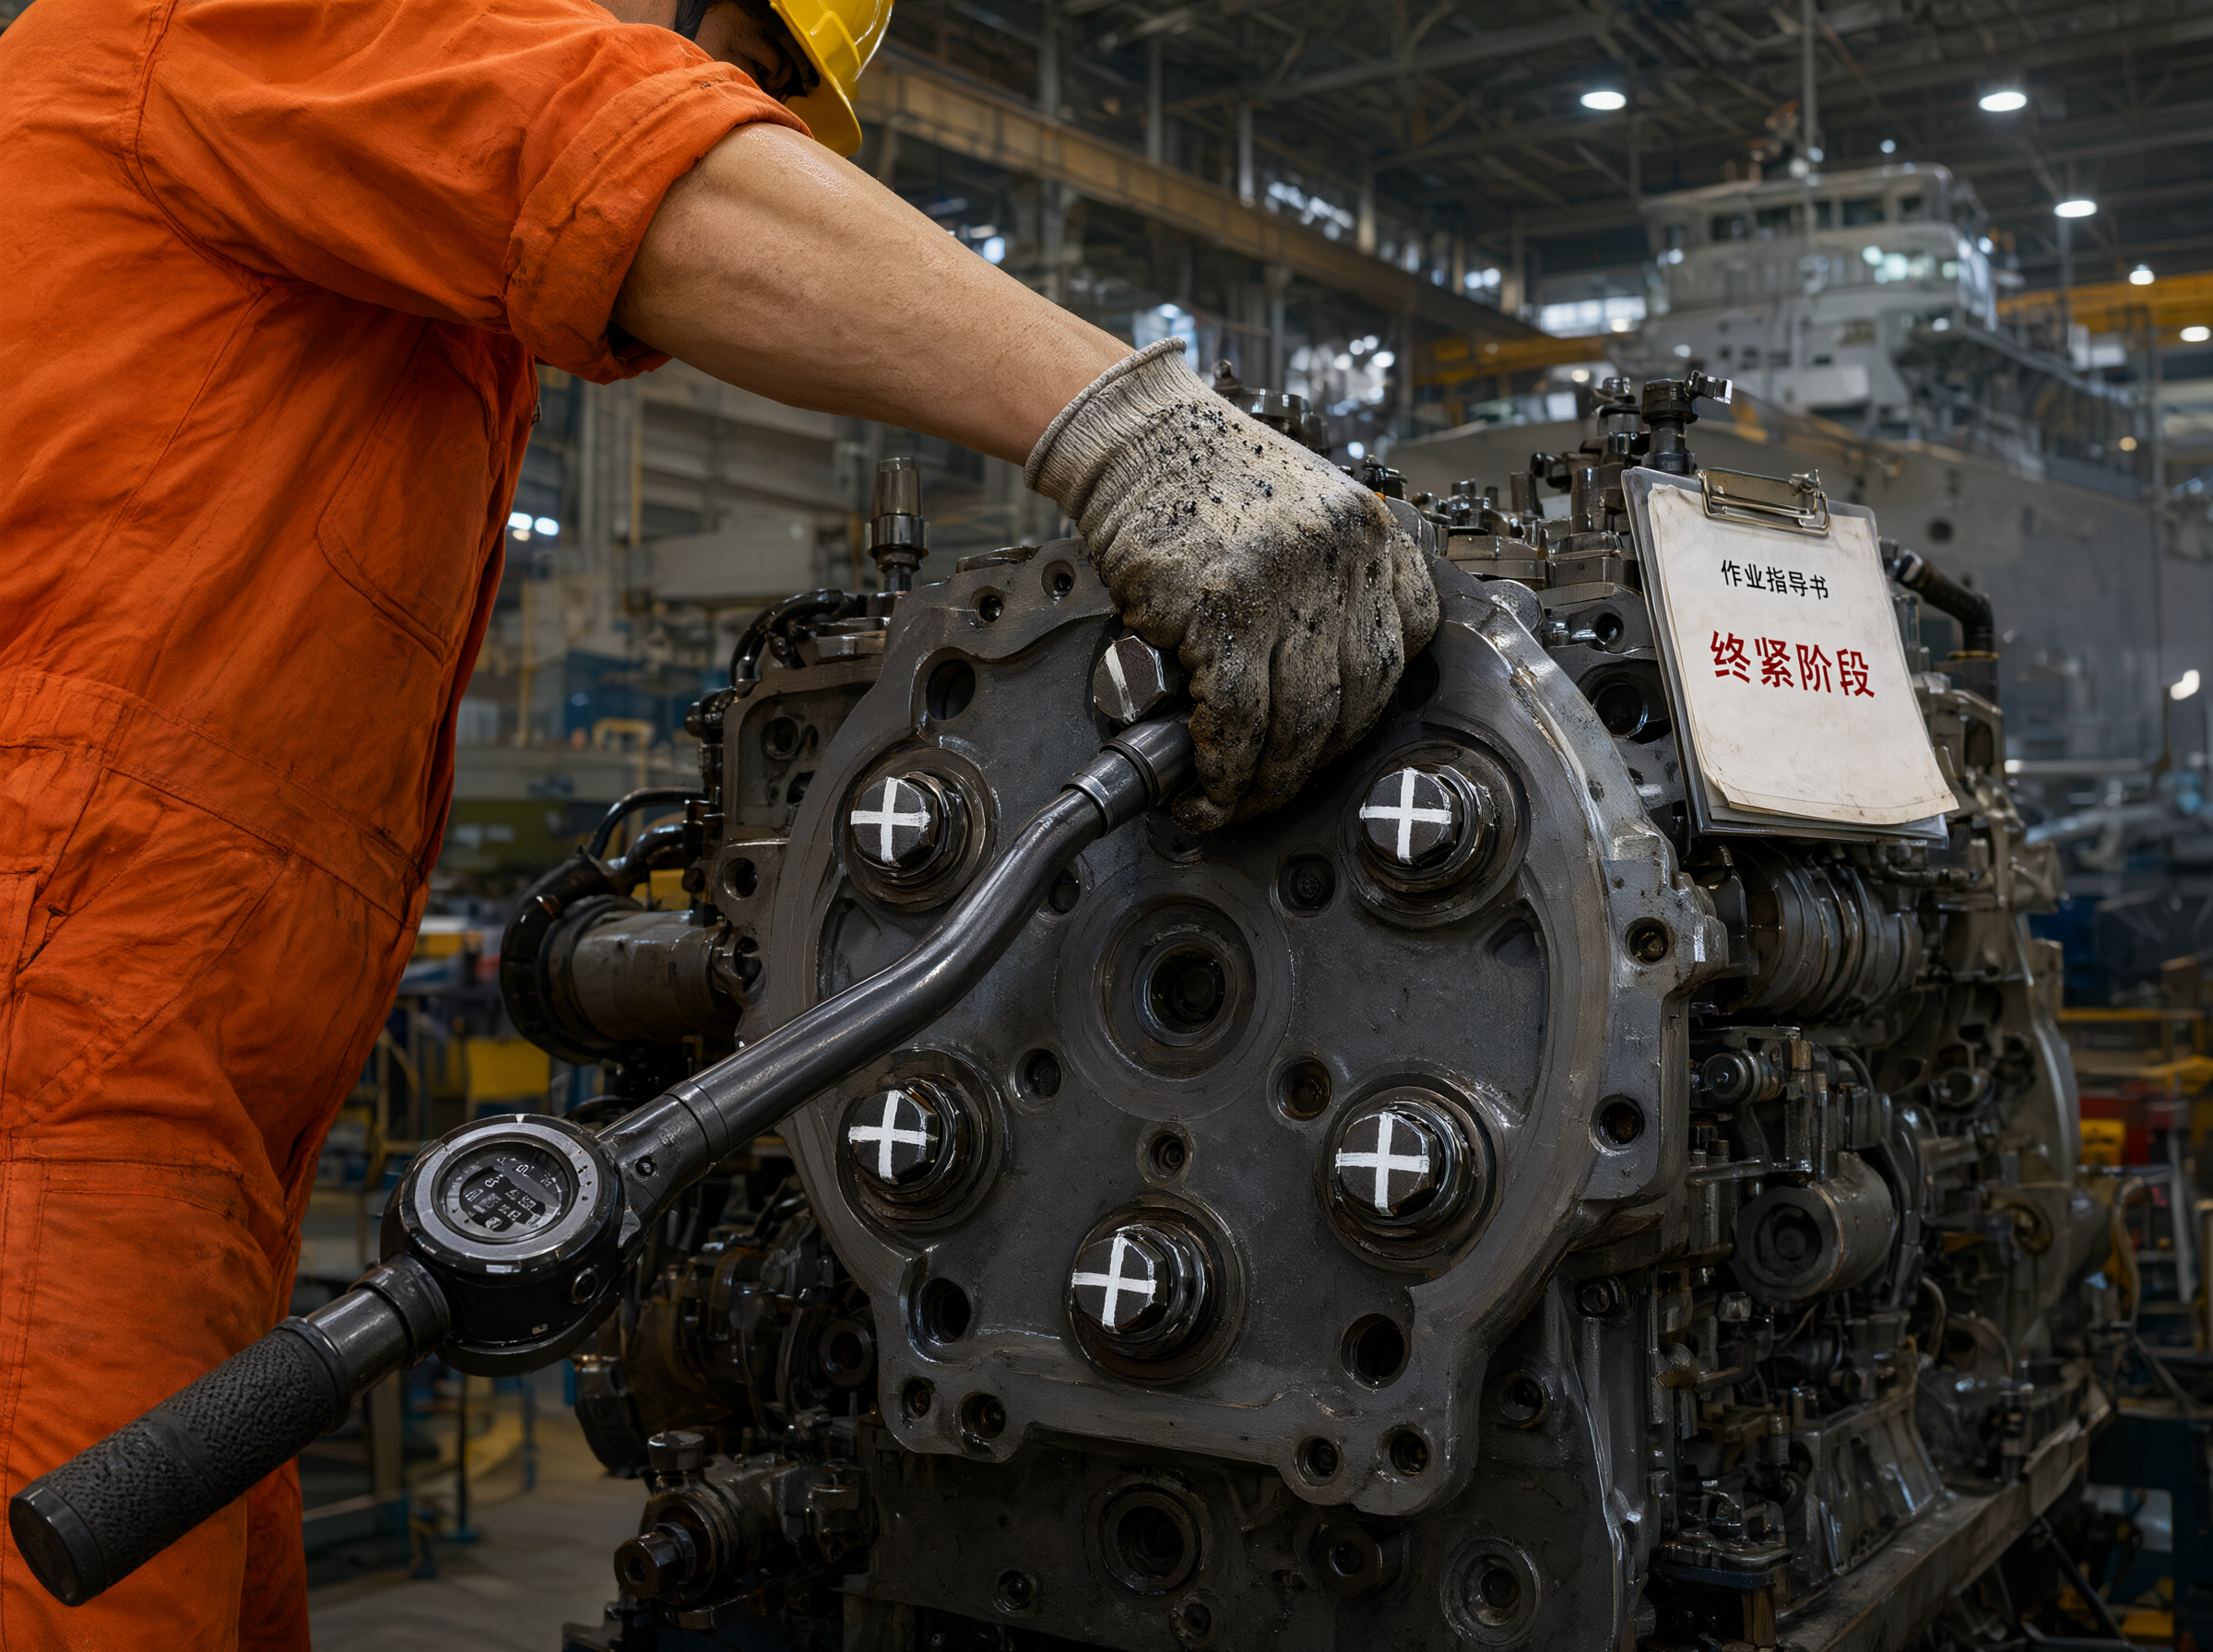

**出题适用性也要检查：** “通常、传统上、可能”不能直接变成所有画面必须满足的规则。若题目未限定情境，合理例外不能判错；若限定后仍无法从画面区分对错，请在依据里注明“知识可能成立，但不适合作为当前核心考点”。

#### 对照下面的原文
先看来源是否讲同一个概念，再看原文是否支持上面整句话，包括范围、条件和例外。引文匹配通过只说明引用存在，不保证知识正确。

**现在判断：** 来源对得上吗？整句知识有依据吗？条件有没有遗漏？内容类型、领域和画面设想是否合理？

都认可才选「认同」；发现问题选「有问题」并说明哪句话；不熟悉或原文看不懂，选「拿不准」。不用为了通过而猜。

看完后去「③ 保存判断」。当前仅展示，尚未保存。


In [18]:
# ② 看一条 —— 不用修改
queue.show()


## ③ 保存判断：看完当前卡片后再运行

只改下面两行引号里的内容：**判断**和**依据**。

| 判断填什么 | 适用情况 | 保存后意味着什么 |
| --- | --- | --- |
| 认同 | 核对后认可当前整张卡的标注 | 知识卡通过；图片卡保留你认可的文生图、编辑结论 |
| 有问题 | 找到具体错误，或者不同意某项结论 | 当前版本不通过，问题留给后续修正 |
| 拿不准 | 自己不熟悉、看不清、原文不足或判断标准不清楚 | 记录疑问，暂不通过 |

**“认同”不等于“图片可用”。** 如果模型说这张图不可用，而你核对后认为它说得对，也可以填“认同”。只有知识卡通过、图片卡通过、且相应用途被认可为可用，才有资格在后续导出时进入核心集。

依据用一句中文说明即可，例如（仅演示写法，不是当前卡的答案）：

- `判断 = "有问题"`，`依据 = "原文说许多螺栓有光杆，知识句子却写成所有螺栓都有。"`
- `判断 = "拿不准"`，`依据 = "我不熟悉这个术语，无法确认原文是否支持这句解释。"`
- `判断 = "认同"`，`依据 = "原文明确支持这句话，适用条件和分类也与原文一致。"`

图片卡如果只有一项不同意，填“有问题”，在依据里指出是文生图还是编辑，以及原因。**不需要你编辑内部 JSON，也不用强行提出修正答案。**

运行后应看到“已保存”。空着任意一项不会保存。每换一条，都要重新填写当前条目的依据，不能沿用上一条。


In [19]:
# ③ 保存判断 —— 每条重新填写这两行，看完当前卡片才运行
queue.reviewer = "vincent"
判断 = "有问题"
依据 = "是有区别，但会不会太咬文嚼字，感觉日常就不太区分对错？这个考点的意义是啥呢"

queue.save_judgment(判断, 依据)


已保存 docs_0893759de6a1e78bd441fbbd_f2 reject
这条已记录。继续时回到「② 看一条」；也可以直接关闭，下次接着做。


## 保存之后怎么办？

继续审核：向上回到 **② 看一条**，运行，然后填写并运行③。今天结束：直接关闭即可，已保存结果留在本地；下次从①开始，会跳过已审核条目。

“有问题”和“拿不准”也会从本轮未审核队列移出，保留记录供后续检查；它们没有被删除，也不会进入核心集。现在只做初轮校准，借你的反馈修正模型和审核标准，不要求你一个人解决所有领域问题。

下面的④只是可选的进度查看，不属于必做步骤。


## ④ 查看剩余数量（可选）

只统计待审核卡，不保存判断，不导出数据。知识卡和图片卡是两种审核工作，数量不能当作最终入选图片数。


In [6]:
# ④ 查看剩余数量 —— 可选
queue.summary()


待审核：知识卡 26 条，图片卡 27 条。
先核对知识，再看图片。今天先做 3 条即可；关闭后可继续，已保存的条目会自动跳过。
接下来运行「② 看一条」，只读展示，不会调用模型或写入审核。


<details>
<summary>补充背景：已有工作和记录放在哪里（不影响审核操作）</summary>

这轮是小批校准：先选材料，再提取带引文的知识，再让模型检查图片。知识陈述与图片分别审核，因为同一条知识可以对应多张图；一张无关图片也不代表知识本身是错的。当前队列先显示知识卡，图片卡中的已知疑点会优先出现。

待审结果来自 `state/curation/core_pilot_v3/`；人工判断单独存储在该批次目录，保留原始模型输出。模型自称“照片”不代表已核实图片来源；已知生成图会明确提示。这个 Notebook 只读取已有结果并保存你主动填写的判断，不调用 8000 或 4001 端口。

后续需要检查问题记录、修订候选知识或图片标注，再重新核验。核心集导出与本页人工审核分开执行；保存一条判断不会自动发布或覆盖原始数据。

</details>
